Getting environment ready

In [2]:
!unrar x Imgs.rar dataset/

Streaming output truncated to the last 5000 lines.
Extracting  dataset/Imgs/116351.jpg                                        8%  OK 
Extracting  dataset/Imgs/116351.png                                        8%  OK 
Extracting  dataset/Imgs/116355.jpg                                        8%  OK 
Extracting  dataset/Imgs/116355.png                                        8%  OK 
Extracting  dataset/Imgs/116365.jpg                                        8%  OK 
Extracting  dataset/Imgs/116365.png                                        8%  OK 
Extracting  dataset/Imgs/11638.jpg                                         8%  OK 
Extracting  dataset/Imgs/11638.png                                         8%  OK 
Extracting  dataset/Imgs/116448.jpg                                        8%  OK 
Extracting  dataset/Imgs/116448.png                                        8%  OK 
Extracting  dataset/Imgs/1164

In [3]:
import os

# This path matches the 'Extracting' lines in your screenshot
path = 'dataset/Imgs/'

# List the first 10 files
files = os.listdir(path)
print(f"Total files found: {len(files)}")
print(files[:10])

Total files found: 6616
['108284.jpg', '100664.png', '133414.png', '130556.png', '115606.jpg', '140991.png', '154580.jpg', '108198.jpg', '142642.jpg', '148414.png']


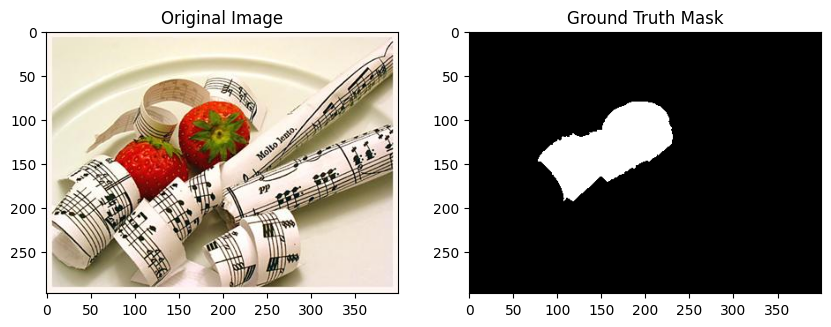

In [4]:
import cv2
import matplotlib.pyplot as plt

# Using one of the filenames from your list
sample_id = '108284'
img_path = f'dataset/Imgs/{sample_id}.jpg'
mask_path = f'dataset/Imgs/{sample_id}.png'

# Load the image and the mask
img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

# Display them
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title("Ground Truth Mask")
plt.show()

In [5]:
import glob

# Get all jpg files and sort them to ensure they match their masks
all_images = sorted(glob.glob('dataset/Imgs/*.jpg'))
all_masks = sorted(glob.glob('dataset/Imgs/*.png'))

print(f"Number of image-mask pairs: {len(all_images)}")

# Check if the first pair matches
print(f"First Image: {all_images[0]}")
print(f"First Mask: {all_masks[0]}")

Number of image-mask pairs: 3308
First Image: dataset/Imgs/100015.jpg
First Mask: dataset/Imgs/100015.png


Resizing and Normalisation

In [6]:
import numpy as np

def load_and_preprocess(image_path, mask_path, target_size=(128, 128)):
    # Load image and resize
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)

    # Load mask, resize, and keep it 1-channel
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, target_size)

    # Normalization (scale pixel values to 0-1)
    img = img.astype('float32') / 255.0
    mask = mask.astype('float32') / 255.0

    # Add a channel dimension to the mask (making it 128x128x1)
    mask = np.expand_dims(mask, axis=-1)

    return img, mask

# Test the function on the first pair
test_img, test_mask = load_and_preprocess(all_images[0], all_masks[0])
print(f"Resized Image Shape: {test_img.shape}")
print(f"Resized Mask Shape: {test_mask.shape}")
print(f"Max pixel value after normalization: {test_img.max()}")

Resized Image Shape: (128, 128, 3)
Resized Mask Shape: (128, 128, 1)
Max pixel value after normalization: 1.0


Splitting the data

In [7]:
from sklearn.model_selection import train_test_split

# First, separate out the Test set (15% of total)
train_imgs, test_imgs, train_masks, test_masks = train_test_split(
    all_images, all_masks, test_size=0.15, random_state=42
)

# Second, split the remaining 85% into Train and Validation
# 0.176 approx results in 15% of the original total for validation
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    train_imgs, train_masks, test_size=0.176, random_state=42
)

print(f"Training pairs: {len(train_imgs)}")
print(f"Validation pairs: {len(val_imgs)}")
print(f"Testing pairs: {len(test_imgs)}")

Training pairs: 2316
Validation pairs: 495
Testing pairs: 497


Data Pipeline

In [8]:
def data_generator(image_paths, mask_paths, batch_size=16):
    while True:
        for i in range(0, len(image_paths), batch_size):
            batch_img_paths = image_paths[i:i+batch_size]
            batch_mask_paths = mask_paths[i:i+batch_size]

            X, Y = [], []
            for img_p, mask_p in zip(batch_img_paths, batch_mask_paths):
                img, mask = load_and_preprocess(img_p, mask_p)
                X.append(img)
                Y.append(mask)

            yield np.array(X), np.array(Y)

# Initialize the generators
train_gen = data_generator(train_imgs, train_masks, batch_size=16)
val_gen = data_generator(val_imgs, val_masks, batch_size=16)

# Test if the generator works
x_test, y_test = next(train_gen)
print(f"Batch X shape: {x_test.shape}") # Should be (16, 128, 128, 3)
print(f"Batch Y shape: {y_test.shape}") # Should be (16, 128, 128, 1)

Batch X shape: (16, 128, 128, 3)
Batch Y shape: (16, 128, 128, 1)


The model

In [9]:
from tensorflow.keras import layers, models

def build_model(input_shape=(128, 128, 3)):
    inputs = layers.Input(input_shape)

    # Encoder (Downsampling)
    conv1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    pool1 = layers.MaxPooling2D((2, 2))(conv1) # Size: 64x64

    conv2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(pool1)
    pool2 = layers.MaxPooling2D((2, 2))(conv2) # Size: 32x32

    # Bottleneck
    conv3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(pool2)

    # Decoder (Upsampling)
    up1 = layers.UpSampling2D((2, 2))(conv3) # Size: 64x64
    conv4 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(up1)

    up2 = layers.UpSampling2D((2, 2))(conv4) # Size: 128x128
    conv5 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(up2)

    # Output Layer (1 channel for the mask, Sigmoid for 0-1 values)
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(conv5)

    model = models.Model(inputs, outputs)
    return model

# Create the model and check the summary
model = build_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 1)    │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,537 (724.75 KB)

 Trainable params: 185,537 (724.75 KB)

 Non-trainable params: 0 (0.00 B)

Compiling and Training

In [10]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Set how many steps to take per epoch
train_steps = len(train_imgs) // 16
val_steps = len(val_imgs) // 16

# Start training!
history = model.fit(
    train_gen,
    steps_per_epoch=train_steps,
    validation_data=val_gen,
    validation_steps=val_steps,
    epochs=10  # We will start with 10 to see progress
)

Epoch 1/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 388s 3s/step - accuracy: 0.7834 - loss: 0.4374 - val_accuracy: 0.8111 - val_loss: 0.3800
Epoch 2/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 381s 3s/step - accuracy: 0.8048 - loss: 0.3901 - val_accuracy: 0.8170 - val_loss: 0.3719
Epoch 3/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 382s 3s/step - accuracy: 0.8139 - loss: 0.3785 - val_accuracy: 0.8196 - val_loss: 0.3616
Epoch 4/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 381s 3s/step - accuracy: 0.8181 - loss: 0.3709 - val_accuracy: 0.8254 - val_loss: 0.3516
Epoch 5/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 380s 3s/step - accuracy: 0.8220 - loss: 0.3632 - val_accuracy: 0.8256 - val_loss: 0.3462
Epoch 6/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 378s 3s/step - accuracy: 0.8252 - loss: 0.3581 - val_accuracy: 0.8353 - val_loss: 0.3410
Epoch 7/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 378s 3s/step - accuracy: 0.8285 - loss: 0.3530 - val_accuracy: 0.8394 - val_loss: 0.3310
Epoch 8/10
144/144 ━━━━━━━━━━━━━━━━━━━━ 382s 3s/step - accuracy: 0.8297 - loss: 0.3506 - val_accu

Visualising results

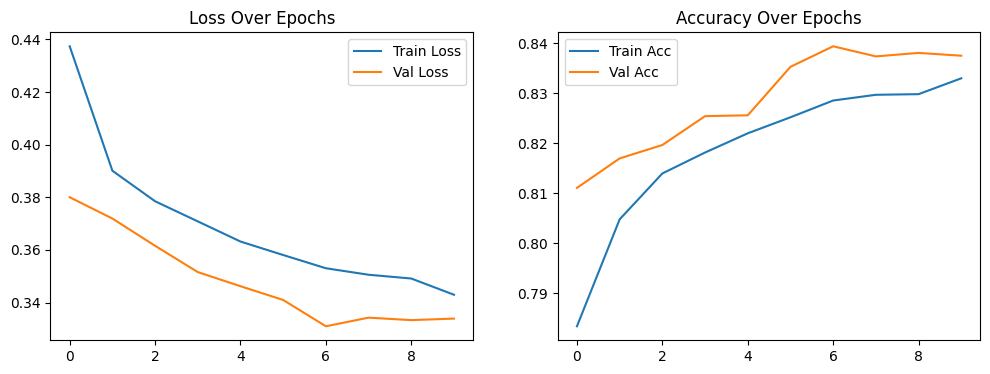

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step


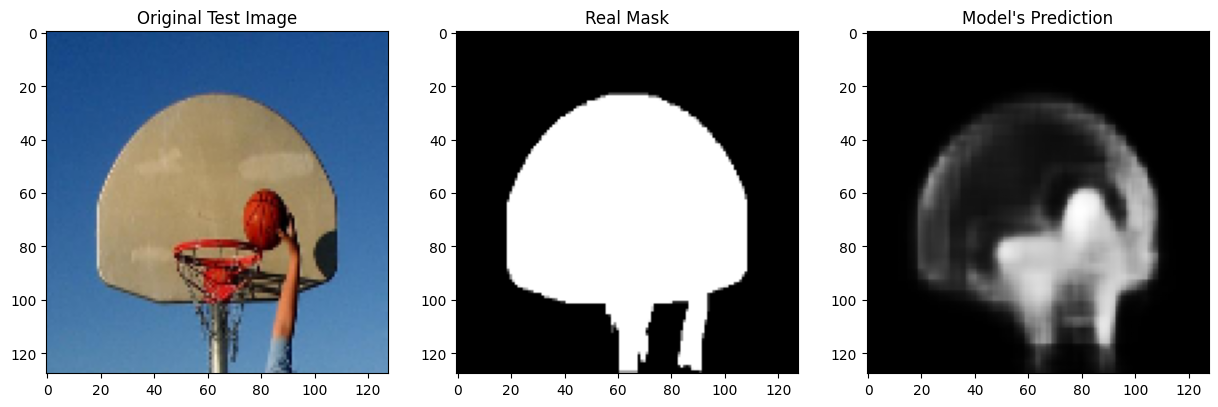

In [11]:
# 1. Plot the Learning Curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Over Epochs')
plt.legend()
plt.show()

# 2. Predict on a Test Image
test_idx = 10  # You can change this number to see different results
img, mask = load_and_preprocess(test_imgs[test_idx], test_masks[test_idx])
prediction = model.predict(np.expand_dims(img, axis=0))[0]

# 3. Show Result
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original Test Image")
plt.subplot(1, 3, 2)
plt.imshow(mask.reshape(128,128), cmap='gray')
plt.title("Real Mask")
plt.subplot(1, 3, 3)
plt.imshow(prediction.reshape(128,128), cmap='gray')
plt.title("Model's Prediction")
plt.show()

Evaluation

In [12]:
# Create a generator for the test set
test_gen = data_generator(test_imgs, test_masks, batch_size=16)
test_steps = len(test_imgs) // 16

# Evaluate the model
results = model.evaluate(test_gen, steps=test_steps)
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")

# Save your model so you don't lose your 30 minutes of work!
model.save('salient_object_model.h5')
print("Model saved as salient_object_model.h5")

31/31 ━━━━━━━━━━━━━━━━━━━━ 22s 724ms/step - accuracy: 0.8372 - loss: 0.3321


Test Loss: 0.3321
Test Accuracy: 0.8372
Model saved as salient_object_model.h5


Select an image from your computer:


Saving 147.jpg to 147.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


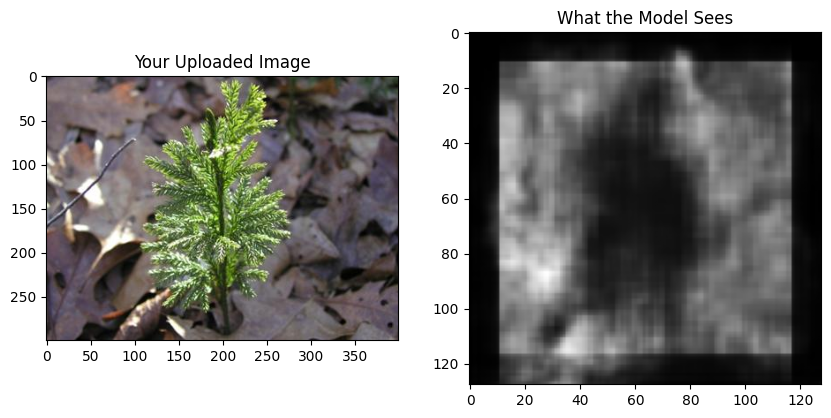

In [14]:
from google.colab import files
import cv2

# 1. Upload your own image
print("Select an image from your computer:")
uploaded = files.upload()

for filename in uploaded.keys():
    # 2. Load and resize it to 128x128 to match the model's training
    raw_img = cv2.imread(filename)
    raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(raw_img, (128, 128)) / 255.0

    # 3. Make the prediction
    pred = model.predict(np.expand_dims(img_resized, axis=0))[0]

    # 4. Show the result
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(raw_img)
    plt.title("Your Uploaded Image")

    plt.subplot(1, 2, 2)
    plt.imshow(pred.reshape(128, 128), cmap='gray')
    plt.title("What the Model Sees")
    plt.show()